<a href="https://colab.research.google.com/github/Anikeje2/Data-Science-Journey/blob/main/Principal_Component_Analysis_Wine_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Conceptual Questions

1) In your own words, explain what PCA does and why it is classified as an unsupervised learning technique.Hint: Think: does PCA use labels? What does it look at?

 Answer: Principal component Analysis (PCA) is a technique used to remove distractions in a dataset. It is a technique used to simplify the data set by reducing the features in the dataset while retaining the important information. Instead of working with a lot of original features it transforms them into smaller sets that still represent the data for example dataset where the features are corelated.
 It is an unsupervised learning technique because it does not use labels or target variables, instead it only looks at independent variables


2) What is the key difference between an original feature (e.g. alcohol) and a principal component? Why can you not say 'PC1 = alcohol'? Hint: Think: linear combinations, new axes.

 Answer: The main difference lies in how they are formed and what they represent. A principal component (PC1) is not the same as an original feature like alcohol because an original feature is a single variable directly measured in the dataset, while a principal component is a new variable created by combining multiple features together. PCA forms principal components as linear combinations of the original features, meaning PC1 is made up of contributions from alcohol and other variables in the dataset. Instead of representing one feature, PC1 represents a new axis that captures the most variation in the data. This is why we cannot say PC1 = alcohol, because PC1 is a mixture of several features, not just one.

3) A classmate says 'I applied PCA and got great results without standardising first.' What mistake did they make and what could go wrong? Hint: Think: variance, feature scales, total_sulfur_dioxide vs pH.

 Answer : Applying PCA without standardising the data is a mistake because PCA is based on variance and is affected by the scale of the features. Features with larger numerical values like total_sulfur_dioxide will dominate the principal components, while features with smaller scales like pH will have very little influence. This means PCA will focus more on the magnitude of the variables rather than the true underlying patterns in the data. As a result, important information from smaller-scale features may be ignored, leading to misleading or biased results. Standardising ensures that all features contribute equally to the analysis.


4) Explain what an eigenvalue tells you in the context of PCA. If PC1 has a much larger eigenvalue than PC2, what does that mean? Hint: Think: how much variance each component captures.

Answer: An eigenvalue in PCA tells you how much variance a principal component captures from the dataset. It shows the amount of information or importance of each principal component. Each principal component has its own eigenvalue, and the higher the eigenvalue, the more variance it explains in the data. If PC1 has a much larger eigenvalue than PC2, it means PC1 captures a much larger portion of the total variance in the dataset compared to PC2. This means PC1 holds more important information about the data, while PC2 contributes less in comparison.

5) Name ONE advantage and ONE disadvantage of PCA. For the disadvantage, describe a real scenario where it would cause a problem. Hint: Think: interpretability, speed, non-linearity.

Answer : Principal Component Analysis (PCA) has the advantage of reducing the number of features in a dataset, which makes computations faster and simplifies the data while still retaining most of the important information. This is useful when working with large datasets as it improves efficiency and reduces complexity. However, a disadvantage of PCA is that it reduces interpretability because the new features (principal components) are combinations of the original variables and are not easily understood. For example, in a medical dataset, if PCA is applied to features like blood pressure, glucose level, and cholesterol, the resulting principal components cannot be easily interpreted by doctors, making it difficult to understand which specific factor is influencing a patient’s condition.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd #importing libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
# Data Loading
df = pd.read_csv('/content/drive/MyDrive/SCA class/wine_quality_pca.csv') #loading file

In [ ]:
# Exploring data
print(df.shape)
print('----------')
print(df.columns)
print('----------')
df.head(5)

(400, 12)
----------
Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality_label'],
      dtype='object')
----------


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality_label
0,8.47,0.200,0.455,4.59,0.076,26.4,120.8,0.99475,3.29,0.65,14.2,High
1,6.76,0.705,0.263,3.75,0.087,24.3,100.8,0.99503,3.32,0.70,9.9,Low
2,8.18,0.759,0.148,6.67,0.108,33.9,128.1,0.99558,3.59,0.65,10.8,Low
3,8.64,0.318,0.352,6.89,0.067,14.9,78.5,0.99587,3.08,0.81,13.1,High
4,7.46,0.397,0.251,3.26,0.050,8.8,39.1,0.99466,3.29,0.74,11.3,Medium


In [ ]:
print(df['quality_label'].value_counts ())
print(df['quality_label'].isnull().sum())# checking for missing quality_label
print(df.isnull().sum()) # checking for missing values in the dataset

quality_label
Medium    166
Low       129
High      105
Name: count, dtype: int64
0
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality_label           0
dtype: int64


In [ ]:
# Feature Standardization
X= df.drop(columns=['quality_label']) # saving all features except quality label in X
y =df['quality_label']  #saving quality_label in y

print(f"Shape of X:{X.shape}") # confirming the shape of X
print (X.describe().round(3)) # exploring X

Shape of X:(400, 11)
       fixed_acidity  volatile_acidity  ...  sulphates  alcohol
count        400.000           400.000  ...    400.000  400.000
mean           7.436             0.518  ...      0.650   10.703
std            1.122             0.163  ...      0.115    1.303
min            4.690             0.120  ...      0.350    7.700
25%            6.570             0.400  ...      0.580    9.700
50%            7.390             0.510  ...      0.650   10.700
75%            8.135             0.630  ...      0.730   11.500
max           10.870             1.033  ...      0.980   14.600

[8 rows x 11 columns]


In [ ]:
from os import X_OK
# Scaling
scaler = StandardScaler() # Scaling X
X_scaled = scaler.fit_transform(X)

X_scaled_df =pd.DataFrame(X_scaled, columns= X.columns)
print(X_scaled_df.mean().round(3)) #confirming mean of scaled X  values is 0
print(X_scaled_df.std().round(2)) # confirming std of scaled X values is 1

print(X_scaled_df.shape) # crosschecking

fixed_acidity          -0.0
volatile_acidity        0.0
citric_acid             0.0
residual_sugar          0.0
chlorides               0.0
free_sulfur_dioxide    -0.0
total_sulfur_dioxide   -0.0
density                 0.0
pH                      0.0
sulphates              -0.0
alcohol                 0.0
dtype: float64
fixed_acidity           1.0
volatile_acidity        1.0
citric_acid             1.0
residual_sugar          1.0
chlorides               1.0
free_sulfur_dioxide     1.0
total_sulfur_dioxide    1.0
density                 1.0
pH                      1.0
sulphates               1.0
alcohol                 1.0
dtype: float64
(400, 11)


Standardisation is necessary before applying Principal Component Analysis (PCA) because PCA is based on variance and is affected by the scale of the features. Features with larger values or wider ranges will dominate the principal components, while features with smaller scales will contribute less. This means the results will be biased towards variables with bigger magnitudes rather than the true patterns in the data. Standardising ensures that all features are on the same scale, so each variable contributes equally to the analysis and the principal components reflect the actual structure of the dataset.

In [ ]:
# PCA implementation
pca= PCA() # creating PCA with no limit
X_PCA = pca.fit_transform(X_scaled) #fitting PCA on X

print(f"origial shape :{X_scaled.shape}")
print(f"Shape after PCA :{X_PCA.shape}")

ev =pca.explained_variance_ratio_ #storing Explained Variance Ratio

print("Explained Variance Ratio:")
print((ev * 100).round(2)) # printing EVR as a percentage
components = range(1, len(ev)+1)


origial shape :(400, 11)
Shape after PCA :(400, 11)
Explained Variance Ratio:
[35.22 13.42  9.48  9.22  8.6   5.62  5.12  4.81  4.32  3.74  0.45]


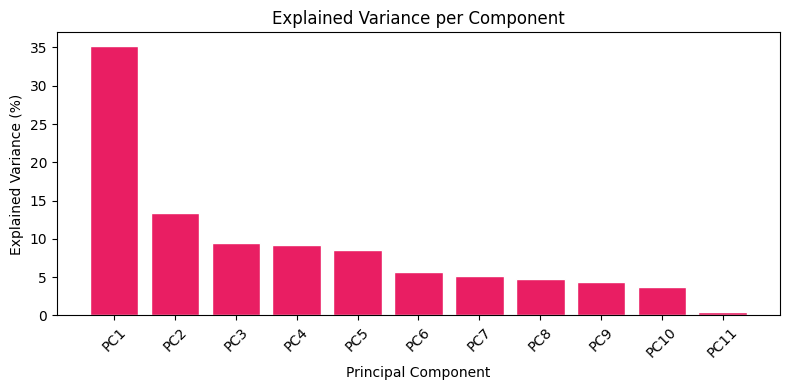

In [ ]:
#plotting explained variance bar chat
plt.figure(figsize=(8,4))
plt.bar(components, ev*100, color='#E91E63', edgecolor='white')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('Explained Variance per Component')
plt.xticks(components, [f'PC{i}' for i in components], rotation=45)
plt.tight_layout()
plt.show()

The elbow point occurs at PC3. After PC2, the explained variance
drops sharply and then begins to level off, indicating diminishing returns
from including additional principal components. This suggests that the first
2–3 principal components capture the most meaningful variance in the data.

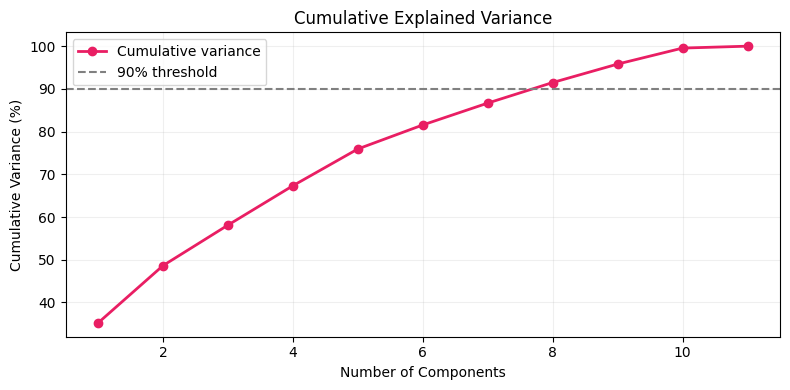

Min components for 90% variance: 8

Cumulative variance at each step:
  1 PCs: 35.2%
  2 PCs: 48.6%
  3 PCs: 58.1%
  4 PCs: 67.3%
  5 PCs: 75.9%
  6 PCs: 81.6%
  7 PCs: 86.7%
  8 PCs: 91.5% ← 90% reached
  9 PCs: 95.8%
  10 PCs: 99.6%
  11 PCs: 100.0%


In [ ]:
# Line chart of cumulative Explained Variance
cumvar = np.cumsum(ev) * 100
components = range(1, len(ev) + 1)

plt.figure(figsize=(8, 4))
plt.plot(components, cumvar,
         color='#E91E63',
         marker='o', linewidth=2,
         label='Cumulative variance')
plt.axhline(y=90, color='gray',
            linestyle='--', linewidth=1.5,
            label='90% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance (%)')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Minimum components for 90% variance
n_90 = np.argmax(cumvar >= 90) + 1
print(f"Min components for 90% variance: {n_90}")
print(f"\nCumulative variance at each step:")
for i, cv in enumerate(cumvar, 1):
    marker = " ← 90% reached" if i == n_90 else ""
    print(f"  {i} PCs: {cv:.1f}%{marker}")

In [ ]:
pca_2 = PCA(n_components=2)   # creating PCA with 2 components
X_pca= pca_2.fit_transform(X_scaled)  # transforming x
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])  #putting results in columns PC1 & PC2
pca_df['quality_label'] = y.values # adding quality label back

print(pca_df.shape)

print(f"Total variance retained: {pca_2.explained_variance_ratio_.sum():.2%}")


(400, 3)
Total variance retained: 48.64%


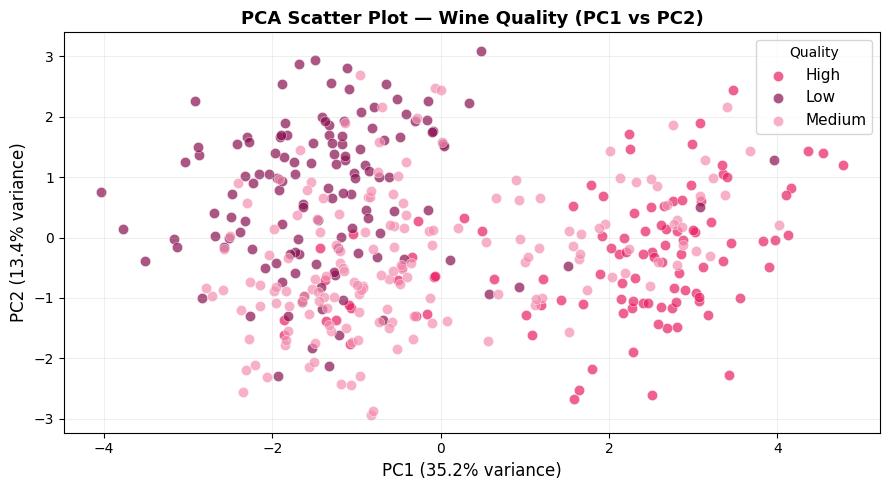

In [ ]:
# PCA Scatter Plot - PC1 vs PC2 coloured by quality label
colors = {'High': '#E91E63', 'Medium': '#F48FB1', 'Low': '#880E4F'}
plt.figure(figsize=(9, 5))
for label, group in pca_df.groupby('quality_label'):
    plt.scatter(
        group['PC1'], group['PC2'],
        label=label,
        color=colors[label],
        alpha=0.7, s=55, edgecolors='white', linewidths=0.4 )
plt.xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]:.1%} variance)", fontsize=12)
plt.ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]:.1%} variance)", fontsize=12)
plt.title("PCA Scatter Plot — Wine Quality (PC1 vs PC2)", fontsize=13, fontweight='bold')
plt.legend(title='Quality', fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

Do the three quality groups form separate clusters?

The three quality groups do not form clearly separate clusters. Looking at the
scatter plot, the High, Medium, and Low points
are heavily mixed together, especially in the centre of the plot around PC1 = -2
to 0. There is no clean boundary separating any of the three groups from each other.

Which axis best separates the quality groups?

PC1 appears to do a slightly better job at separating the groups since it
explains 35.2% of the variance compared to PC2's 13.4%. Looking at the plot,
Medium quality wines tend to appear more on the right side (higher PC1 values),
while Low and High wines are more concentrated on the left. However, the
separation is weak and not definitive. This suggests that the features most
responsible for wine quality differences are partially captured in PC1.

Are there overlapping groups? What might explain this?

Yes, there is significant overlap between all three groups across both axes.
This could be because wine quality is determined by a complex combination of
original features like acidity, alcohol, and sulphates that do not separate
cleanly when compressed into just two components. PCA also retains only 48.6%
of the total variance with 2 components, meaning a large amount of information
that could help distinguish quality groups has been lost in the reduction.

Would you recommend PCA before training a classifier?

Yes, but with conditions. PCA is useful as a pre-processing step because it
removes correlated features and reduces noise, which can improve model
training speed and reduce overfitting. However, based on this scatter plot the
2-component version alone would not be enough for a classifier since the groups
overlap too much. I would recommend using more components, for example the 7
needed to reach 90% variance, before feeding the data into a classifier. This
way the model benefits from dimensionality reduction without losing too much
of the information needed to distinguish wine quality.